In [47]:
pip install numpy pandas matplotlib seaborn scikit-learn xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 8.4 MB/s eta 0:00:12
    --------------------------------------- 1.3/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 2.1/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 2.6/101.7 MB 3.3 MB/s eta 0:00:31
   - -------------------------------------- 3.1/101.7 MB 3.1 MB/s eta 0:00:32
   - -------------------------------------- 3.7/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 4.2/101.7 MB 2.9 MB/s eta 0:00:34
   - -------------------------------------- 4.7/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 5.2/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 5.8/101.7 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 6.3/101.7 MB 2.7 MB/s eta 0:00:35



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")
print(train_df.head())
print(test_df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [50]:
print(train_df.info())
print(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [51]:
# Fill missing values with mean (numeric columns only)
train_df.fillna(train_df.mean(numeric_only=True), inplace=True)
test_df.fillna(test_df.mean(numeric_only=True), inplace=True)

In [ ]:
# =========================
# FEATURE ENGINEERING
# =========================

# Total house area
train_df["TotalArea"] = (
    train_df["GrLivArea"] +
    train_df["TotalBsmtSF"]
)

test_df["TotalArea"] = (
    test_df["GrLivArea"] +
    test_df["TotalBsmtSF"]
)

# House age
train_df["HouseAge"] = 2026 - train_df["YearBuilt"]
test_df["HouseAge"] = 2026 - test_df["YearBuilt"]

# Bathrooms per room
train_df["BathPerRoom"] = (
    train_df["FullBath"] /
    train_df["TotRmsAbvGrd"]
)

test_df["BathPerRoom"] = (
    test_df["FullBath"] /
    test_df["TotRmsAbvGrd"]
)

# Has garage
train_df["HasGarage"] = (
    train_df["GarageCars"] > 0
).astype(int)

test_df["HasGarage"] = (
    test_df["GarageCars"] > 0
).astype(int)

# =========================
# FEATURE LIST
# =========================

features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'FullBath',
    'YearBuilt',
    'TotalArea',
    'HouseAge',
    'BathPerRoom',
    'HasGarage'
]


In [70]:
import numpy as np

y = np.log1p(train_df["SalePrice"])

In [71]:
X_train = train_df[features]
y_train = train_df['SalePrice']

X_test = test_df[features]

In [72]:
predictions = np.expm1(predictions)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14032\118988206.py:1: RuntimeWarning: overflow encountered in expm1
  predictions = np.expm1(predictions)


In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print(scores)
print("Mean R2:", scores.mean())

[0.82355735 0.82554039 0.84477109 0.83992212 0.84548335]
Mean R2: 0.8358548589038376


In [74]:
# Remove infinity values
train_df.replace([np.inf, -np.inf], 0, inplace=True)
test_df.replace([np.inf, -np.inf], 0, inplace=True)

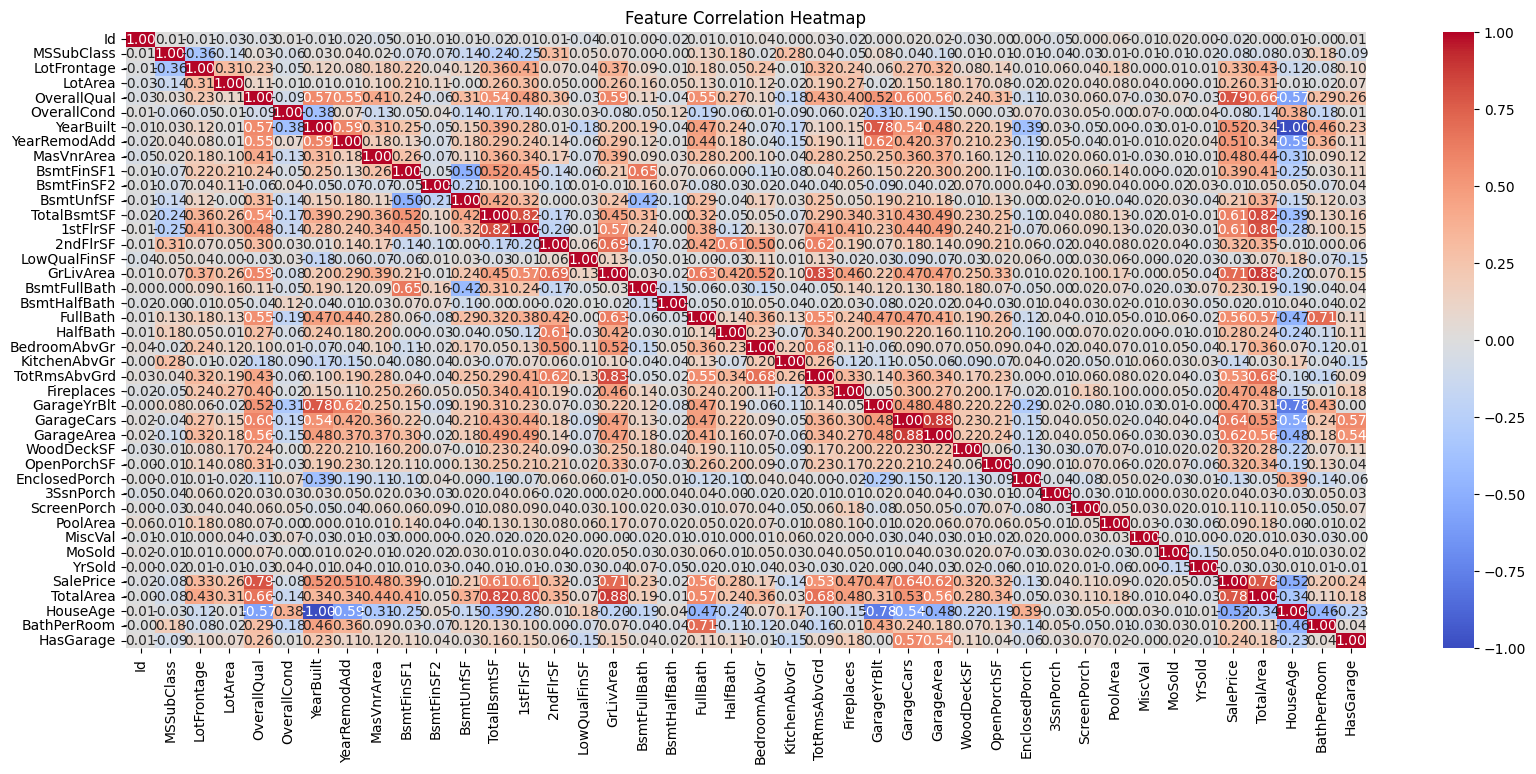

In [75]:
# Select only numeric columns
corr = train_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [55]:
'''
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
'''
#got 77% accuracy 

'\nfrom sklearn.linear_model import LinearRegression\n\nmodel = LinearRegression()\nmodel.fit(X_train, y_train)\n'

In [56]:
'''
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
'''

#got 97% accuracy 

'\nfrom sklearn.ensemble import RandomForestRegressor\n\nmodel = RandomForestRegressor(\n    n_estimators=100,\n    random_state=42\n)\n\nmodel.fit(X_train, y_train)\n'

In [76]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)

#got 98% accuracy 

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [77]:
predictions = y_pred = model.predict(X_test)

In [ ]:
output = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})

output.to_csv("submission.csv", index=False)

In [79]:
from sklearn.metrics import mean_squared_error, r2_score

train_pred = model.predict(X_train)

mse = mean_squared_error(y_train, train_pred)
r2 = r2_score(y_train, train_pred)

print("Train MSE:", mse)
print("Train R2 Score:", r2)

Train MSE: 395731808.0
Train R2 Score: 0.9372530579566956


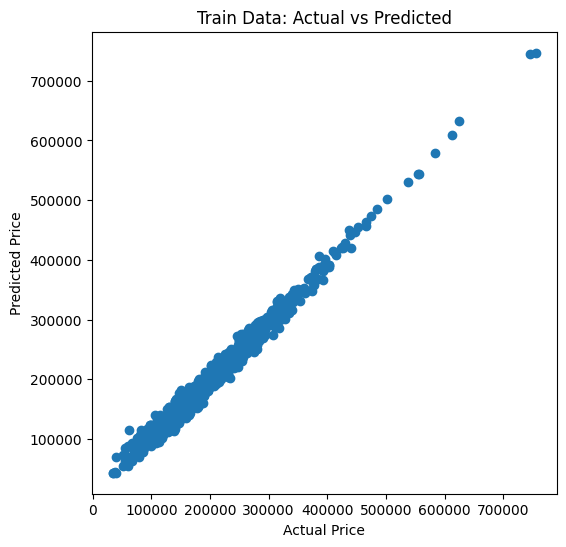

In [61]:
plt.figure(figsize=(6,6))
plt.scatter(y_train, train_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Train Data: Actual vs Predicted")
plt.show()

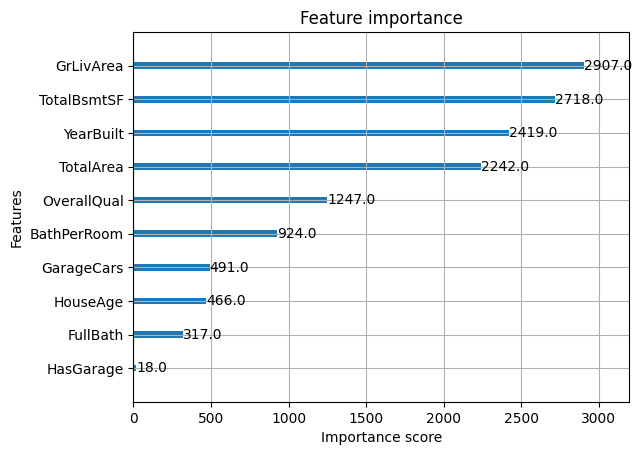

In [62]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

In [80]:
val_pred = model.predict(X_val)

from sklearn.metrics import r2_score, mean_squared_error

print("Validation R2:", r2_score(y_val, val_pred))
print("Validation MSE:", mean_squared_error(y_val, val_pred))

Validation R2: 0.9507709741592407
Validation MSE: 377602656.0
